In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mne
from pathlib import Path
from scipy import signal
from scipy.signal import welch
from asrpy import ASR
import warnings
warnings.filterwarnings('ignore')

In [3]:
data_dir = Path("/Users/folasewaabdulsalam/Downloads/EEG_Based_Mental_Workload_Classifier/EEG-Based_Mental_Workload_Classifier/data")

channel_names = ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4']

sampling_frequency = 128

#intialize
all_data = []
all_subjects = []
all_workload = []

for file in sorted(data_dir.glob("*.txt")):
    filename = file.stem
    parts = filename.split("_")
    subject = parts[0]
    workload = parts[1]

    eeg_data = np.loadtxt(file)
    all_data.append(eeg_data)
    all_subjects.append(subject)
    all_workload.append(workload)
print(f"Successfully loaded {len(all_data)} files")

Successfully loaded 96 files


Creating RawArray with float64 data, n_channels=14, n_times=19200
    Range : 0 ... 19199 =      0.000 ...   149.992 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 423 samples (3.305 s)

The raw data shape: (19200, 14)
The filtered data shape: (19200, 14)


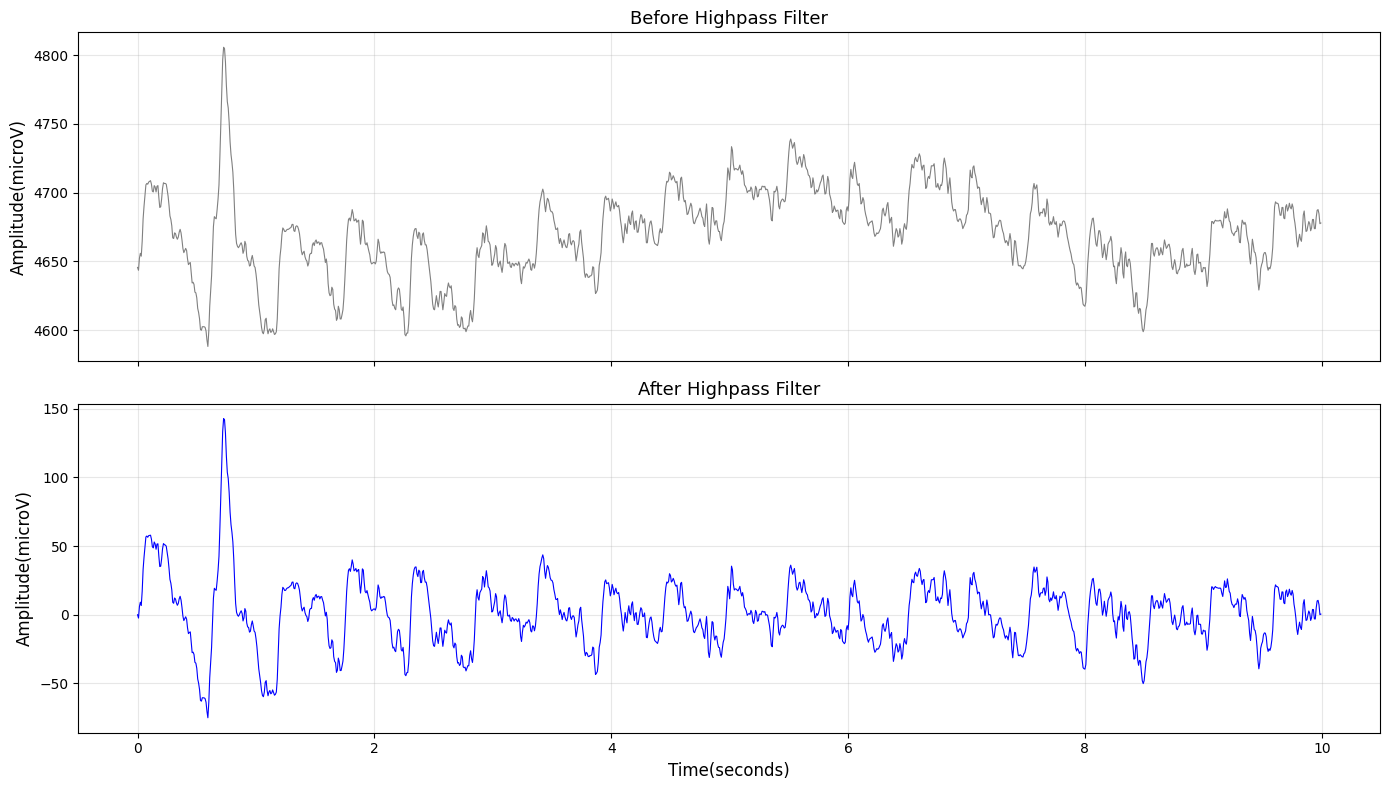

In [ ]:
#preprocessing steps
#Step1. High pass filter at 1hz
#on first subject, low workload

sub01_lo_idx = None
sub01_hi_idx = None

for i in range(len(all_subjects)):
    if all_subjects[i] == 'sub01' and all_workload[i] == "lo":
        sub01_lo_idx = i
    if all_subjects[i] == 'sub01' and all_workload[i] == 'hi':
        sub01_hi_idx = i
sub01_lo = all_data[sub01_lo_idx]
sub01_hi = all_data[sub01_hi_idx]

#creating mne info
info = mne.create_info(ch_names = channel_names, sfreq=sampling_frequency, ch_types = 'eeg')
raw_sub01 = mne.io.RawArray(sub01_lo.T, info)

#applying the high-pass
filtered_raw_sub01 = raw_sub01.copy().filter(l_freq=1.0, h_freq=None)
filtered_sub01 = filtered_raw_sub01.get_data().T

print(f"The raw data shape: {sub01_lo.shape}")
print(f"The filtered data shape: {filtered_sub01.shape}")

#visualizing the effect of high-pass filtering the data
duration = 10
samples = sampling_frequency * duration
time = np.arange(samples)/sampling_frequency

fig, axes = plt.subplots(2, 1, figsize=(14,8), sharex=True)

#before plotting
axes[0].plot(time, sub01_lo[:samples, 0], linewidth=0.8, color='gray')
axes[0].set_ylabel("Amplitude(microV)", fontsize=12)
axes[0].set_title("Before Highpass Filter", fontsize=13)
axes[0].grid(alpha=0.3)

axes[1].plot(time, filtered_sub01[:samples, 0], linewidth=0.8, color='blue')
axes[1].set_ylabel("Amplitude(microV)", fontsize=12)
axes[1].set_xlabel("Time(seconds)", fontsize=12)
axes[1].set_title("After Highpass Filter", fontsize=13)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()



Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 845 samples (6.602 s)

Notch filtering at 60Hz complete!


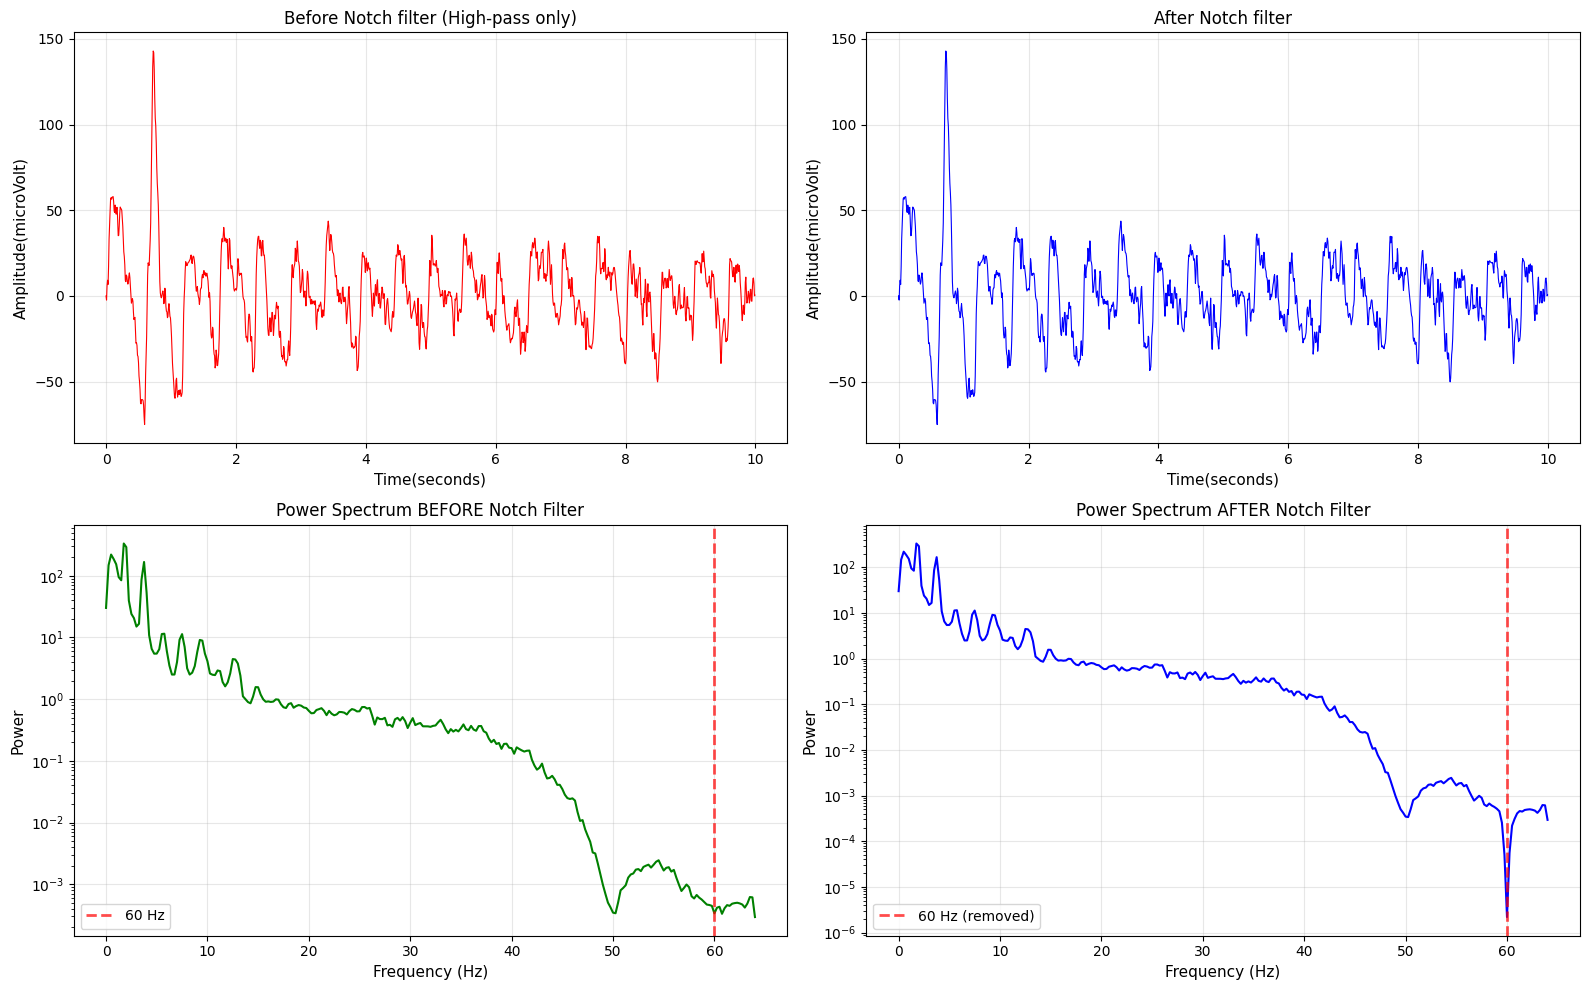

In [10]:
#step2: Remove line noise
#note that electrical line noise is 50hz for Europe and 60Hz for US

raw_notched = filtered_raw_sub01.copy().notch_filter(freqs=60)
notched_sub01 = raw_notched.get_data().T
print("Notch filtering at 60Hz complete!")

#visualizing in time and frequency domains
fig, axes = plt.subplots(2,2, figsize=(16,10))
#time domain (Before notch)
axes[0,0].plot(time, filtered_sub01[:samples, 0], linewidth=0.8, color='red')
axes[0,0].set_ylabel("Amplitude(microVolt)", fontsize=11)
axes[0,0].set_xlabel("Time(seconds)", fontsize=11)
axes[0,0].set_title("Before Notch filter (High-pass only)", fontsize=12)
axes[0,0].grid(alpha=0.3)

#time domain (After notch)
axes[0,1].plot(time, notched_sub01[:samples, 0], linewidth=0.8, color='blue')
axes[0,1].set_ylabel("Amplitude(microVolt)", fontsize=11)
axes[0,1].set_xlabel("Time(seconds)", fontsize=11)
axes[0,1].set_title("After Notch filter", fontsize=12)
axes[0, 1].grid(alpha=0.3)

#frequency domain (Before notch)
freqs_before, psd_before = welch(filtered_sub01[:, 0], fs=sampling_frequency,nperseg=512, noverlap=256)
freqs_after, psd_after = welch(notched_sub01[:, 0], fs=sampling_frequency,nperseg=512, noverlap=256)

freq_range = freqs_before <=64 #0-64hz frequency range
axes[1,0].semilogy(freqs_before[freq_range], psd_before[freq_range], linewidth=1.5, color = 'green')
axes[1, 0].axvline(60, color='red', linestyle='--', linewidth=2, alpha=0.7, label='60 Hz')
axes[1, 0].set_ylabel('Power', fontsize=11)
axes[1, 0].set_xlabel('Frequency (Hz)', fontsize=11)
axes[1, 0].set_title('Power Spectrum BEFORE Notch Filter', fontsize=12)
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

#frequency domain (After Notch)
axes[1, 1].semilogy(freqs_after[freq_range], psd_after[freq_range], linewidth=1.5, color='blue')
axes[1, 1].axvline(60, color='red', linestyle='--', linewidth=2, alpha=0.7, label='60 Hz (removed)')
axes[1, 1].set_ylabel('Power', fontsize=11)
axes[1, 1].set_xlabel('Frequency (Hz)', fontsize=11)
axes[1, 1].set_title('Power Spectrum AFTER Notch Filter', fontsize=12)
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
#Step3: Artifact Subspace Reconstruction
raw_for_asr = mne.io.RawArray(notched_sub01.T, info)
asr = ASR(sfreq=sampling_frequency, cutoff=5)
asr.fit(raw_for_asr)
raw_after_asr = asr.transform(raw_for_asr)

print("ASR complete")


#step4: Rereferencing to Average

raw_reref = raw_after_asr.copy().set_eeg_reference(ref_channels='average')
# Convert back to numpy (samples, channels)
preprocessed_data = raw_reref.get_data().T
print("Re-referenced to average!")
print(f"Final preprocessed data shape: {preprocessed_data.shape}")

Creating RawArray with float64 data, n_channels=14, n_times=19200
    Range : 0 ... 19199 =      0.000 ...   149.992 secs
Ready.
ASR complete
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Re-referenced to average!
Final preprocessed data shape: (19200, 14)
